In [1]:
import torch
import matplotlib.pyplot as plt
from typing import Tuple 
import os
import matplotlib.pyplot as plt
from skfmm import distance
from torch.utils.data import DataLoader
from torchvision.datasets import OxfordIIITPet
import preprocess_dataset
import losses
from main_network import DecompositionNetwork
import importlib
importlib.reload(losses)
from tqdm import tqdm
from torchsummary import summary

In [2]:
# Hyperparameters:
LEARNING_RATE = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
NUM_EPOCHS = 3
LOAD_MODEL = False
NUM_WORKERS = os.cpu_count()


In [3]:
train_dataset = preprocess_dataset.OxfordIIITPet_Distancefields_train()
test_dataset = preprocess_dataset.OxfordIIITPet_Distancefields_test()

In [4]:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


In [5]:
def train(loader, model, optimizer, loss_fn, scaler, device):
    model = model.to(device)

    # data is rgb without background taken out
    # target is in first dim the y_mask and second dim is distance field
    for data, targets in (pbar := tqdm(loader)):
        # take out the background by applying GT mask
        masked_data = preprocess_dataset.mask_rgb_imgs(data, targets)
        masked_data = masked_data.float().to(device)
        targets = targets.float().to(device)

        optimizer.zero_grad()


        # forward pass
        with torch.cuda.amp.autocast():
            predictions = model(masked_data)
            loss = loss_fn(
                predictions, 
                mask_y=torch.squeeze(targets[:][0][0]),
                field_y=torch.squeeze(targets[:][0][1]),
                device=device
                )

        # backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # update tqdm loop
        pbar.set_postfix(loss=float(loss.item()))

In [6]:
model = DecompositionNetwork(batch_size=BATCH_SIZE)
optim = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scaler = torch.cuda.amp.GradScaler()
# summary(model.to(device=DEVICE), (3, 256, 256))


for epoch in range(NUM_EPOCHS):
    train(train_dataloader, model, optim, losses.all_loss_fn, scaler, device=DEVICE)

model.to(device="cpu")
torch.cuda.empty_cache()

100%|██████████| 230/230 [00:25<00:00,  9.07it/s, loss=4.1]  


tensor([[  1.9611,   3.2237, 269.3569, 306.9498],
        [  2.0316,   2.9242, 256.0807, 292.7492],
        [  2.5000,   4.0567, 247.4183, 278.7210],
        [  1.4488,   1.3679, 271.3626, 308.6072],
        [  2.0186,   2.2827, 263.9019, 299.6304],
        [  2.3538,   4.2700, 273.5805, 311.3883],
        [  1.6288,   1.7387, 271.3465, 307.0744],
        [  1.9156,   2.6991, 267.7446, 304.2003],
        [  2.1096,   3.0304, 261.7122, 297.0166],
        [  2.1730,   2.8669, 268.1973, 305.8243],
        [  2.2909,   3.7315, 267.1239, 305.3245],
        [  3.3166,   5.9112, 281.1804, 317.1109],
        [  0.8774,  -0.3289, 271.6656, 308.8690],
        [  1.8447,   1.9759, 243.1595, 276.3607],
        [  2.1684,   3.7264, 265.6354, 303.5244],
        [  2.5623,   5.0173, 259.4976, 296.5598]], grad_fn=<AddmmBackward0>)


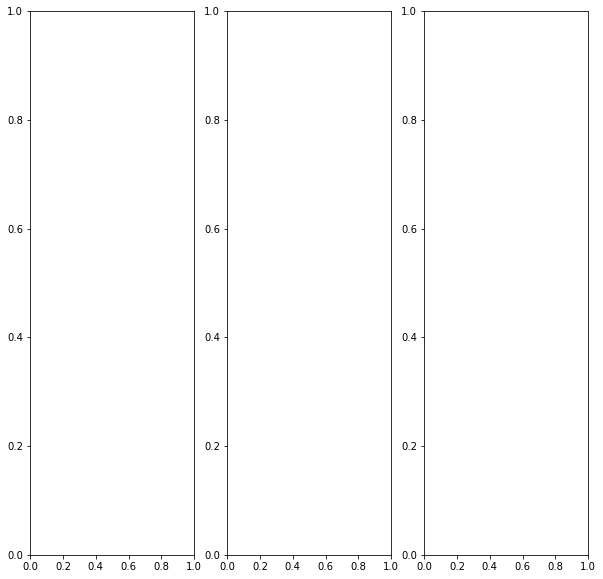

In [7]:
_, ax = plt.subplots(1,3, figsize=(10,10))
for x,y in test_dataloader:
    x_masked = preprocess_dataset.mask_rgb_imgs(x,y)
    predict= model(x_masked.float())
    print(predict)
    break
    # ax[0].imshow(torch.permute(x_masked[0], (1,2,0)), cmap="gray")
    # ax[1].imshow(torch.squeeze(y[0][0]), cmap="gray")
    # ax[2].imshow(torch.squeeze(y[0][1]), cmap="gray")
    # break